# Full Pipeline Tutorial

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/McGrathLab/AquaCal/blob/main/docs/tutorials/01_full_pipeline.ipynb)

This tutorial demonstrates the complete AquaCal calibration pipeline from start to finish, using
fast synthetic data. You'll learn how to:

- Load synthetic calibration data
- Run the calibration pipeline (in-air intrinsic calibration, extrinsic initialization via
  best-first pose-graph traversal, and joint refractive bundle adjustment)
- Visualize camera rig geometry and calibration quality
- Diagnose calibration results with reprojection and 3D error analysis

For a real-hardware walkthrough using the CLI, see the [CLI tutorial](03_cli_walkthrough.md).

**Prerequisites:** Basic Python and OpenCV knowledge. Familiarity with camera calibration concepts is helpful but not required.

In [1]:
# Colab setup installs AquaCal from PyPI if running on Google Colab.
# When running locally, this cell is a no-op.
import sys

if "google.colab" in sys.modules:
    print("Colab detected — installing AquaCal...")
    !pip install -q aquacal
    print("Done.")
else:
    print("Local environment — skipping install.")

Local environment — skipping install.


## Data Source Selection

Choose your data source:

- **`synthetic-small`** (recommended for first run): 4 cameras, 20 frames, ideal conditions (no noise). Fast, no download required. Uses the same "ideal" scenario as the small preset in the [synthetic validation tutorial](02_synthetic_validation.ipynb).
- **`synthetic-large`**: 12 cameras matching the real hardware rig, 30 frames, 0.5 px noise. Slower but produces compelling diagnostics. Uses the same "realistic" scenario as the large preset in the [synthetic validation tutorial](02_synthetic_validation.ipynb).

For a real-hardware walkthrough, see the [CLI tutorial](03_cli_walkthrough.md), which downloads
the full example dataset and runs calibration via the CLI.

In [2]:
DATA_SOURCE = "synthetic-small"  # Options: "synthetic-small", "synthetic-large"

## Setup and Imports

We'll import the necessary modules and configure matplotlib for inline plotting.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from aquacal.calibration import calibrate_from_detections
from aquacal.core.board import BoardGeometry
from aquacal.datasets import create_scenario, generate_synthetic_detections
from aquacal.validation.diagnostics import plot_camera_rig, plot_per_camera_error, plot_error_distribution
from aquacal.validation.reprojection import compute_reprojection_errors

# Configure matplotlib
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10

print("Imports complete!")

Imports complete!


## Load Data and Calibrate

This cell loads data and produces a `CalibrationResult` — the central object for all
subsequent analysis: generate a scenario with `create_scenario()`, produce synthetic
detections, then run calibration Stages 2-3 (extrinsic initialization and joint refractive
bundle adjustment).

In [4]:
# These will be set by the data-source branch below:
#   result     — CalibrationResult (always)
#   scenario   — SyntheticScenario with ground truth (always, this notebook is synthetic-only)
#   detections — DetectionResult (always)
#   board      — BoardGeometry (always)

scenario = None
detections = None
board_poses = None
reprojection_result = None

if DATA_SOURCE in ("synthetic-small", "synthetic-large"):
    # --- Create scenario ---
    # "synthetic-small" uses create_scenario("ideal"):  4 cameras, 20 frames, 0 noise
    # "synthetic-large" uses create_scenario("realistic"): 12 cameras, 30 frames, 0.5px noise
    scenario_name = "ideal" if DATA_SOURCE == "synthetic-small" else "realistic"
    scenario = create_scenario(scenario_name, seed=42)
    print(f"Created scenario: {scenario.description}")
    print(f"  Cameras: {len(scenario.intrinsics)}, Frames: {len(scenario.board_poses)}, Noise: {scenario.noise_std} px")

    board = BoardGeometry(scenario.board_config)

    # --- Generate detections ---
    print("Generating synthetic detections...")
    detections = generate_synthetic_detections(
        intrinsics=scenario.intrinsics,
        extrinsics=scenario.extrinsics,
        water_zs=scenario.water_zs,
        board=board,
        board_poses=scenario.board_poses,
        noise_std=scenario.noise_std,
        seed=42,
    )

    # --- Run Stages 2-3 ---
    print("Running calibration (Stages 2-3)...")
    result, board_poses = calibrate_from_detections(
        detections, scenario.intrinsics, board,
    )

    # Compute detailed reprojection errors for later analysis
    reprojection_result = compute_reprojection_errors(result, detections, board_poses)
    print(f"\nCalibration complete!  RMS: {result.diagnostics.reprojection_error_rms:.3f} px")

else:
    raise ValueError(
        f"Unknown DATA_SOURCE: {DATA_SOURCE!r}. Options: 'synthetic-small', 'synthetic-large'."
    )

Created scenario: Ideal conditions: 4 cameras, 20 frames, 0 noise, real-rig standoff
  Cameras: 4, Frames: 20, Noise: 0.0 px
Generating synthetic detections...


Running calibration (Stages 2-3)...



Calibration complete!  RMS: 0.000 px


## Exploring the Result

Every calibration produces a `CalibrationResult` containing per-camera parameters,
interface geometry, and diagnostic metrics.

In [5]:
cam_names_sorted = sorted(result.cameras.keys())
print(f"Cameras ({len(cam_names_sorted)}): {cam_names_sorted}")

print(f"\nBoard: {result.board.squares_x}x{result.board.squares_y}, "
      f"{result.board.square_size * 1000:.1f} mm squares")

print(f"\nInterface: n_air={result.interface.n_air}, n_water={result.interface.n_water}")

print(f"\nDiagnostics:")
print(f"  Reprojection RMS: {result.diagnostics.reprojection_error_rms:.3f} px")
if result.diagnostics.validation_3d_error_mean > 0:
    print(f"  3D error mean:    {result.diagnostics.validation_3d_error_mean * 1000:.2f} mm")
    print(f"  3D error std:     {result.diagnostics.validation_3d_error_std * 1000:.2f} mm")

print(f"\nWater surface Z per camera:")
for cam in cam_names_sorted:
    cc = result.cameras[cam]
    C = cc.extrinsics.C
    h_c = cc.water_z - C[2]
    print(f"  {cam}: water_z = {cc.water_z:.4f} m, "
          f"C = [{C[0]:.3f}, {C[1]:.3f}, {C[2]:.3f}], h_c = {h_c:.4f} m")

Cameras (4): ['cam0', 'cam1', 'cam2', 'cam3']

Board: 12x9, 60.0 mm squares

Interface: n_air=1.0, n_water=1.333

Diagnostics:
  Reprojection RMS: 0.000 px

Water surface Z per camera:
  cam0: water_z = 1.0310 m, C = [0.000, 0.000, 0.000], h_c = 1.0310 m
  cam1: water_z = 1.0310 m, C = [0.100, 0.000, 0.000], h_c = 1.0310 m
  cam2: water_z = 1.0310 m, C = [-0.000, 0.100, -0.000], h_c = 1.0310 m
  cam3: water_z = 1.0310 m, C = [0.100, 0.100, -0.000], h_c = 1.0310 m


## Camera Rig Geometry

A 3D plot of the camera positions and orientations from the calibration result.
The water surface plane is shown at the estimated Z-coordinate.

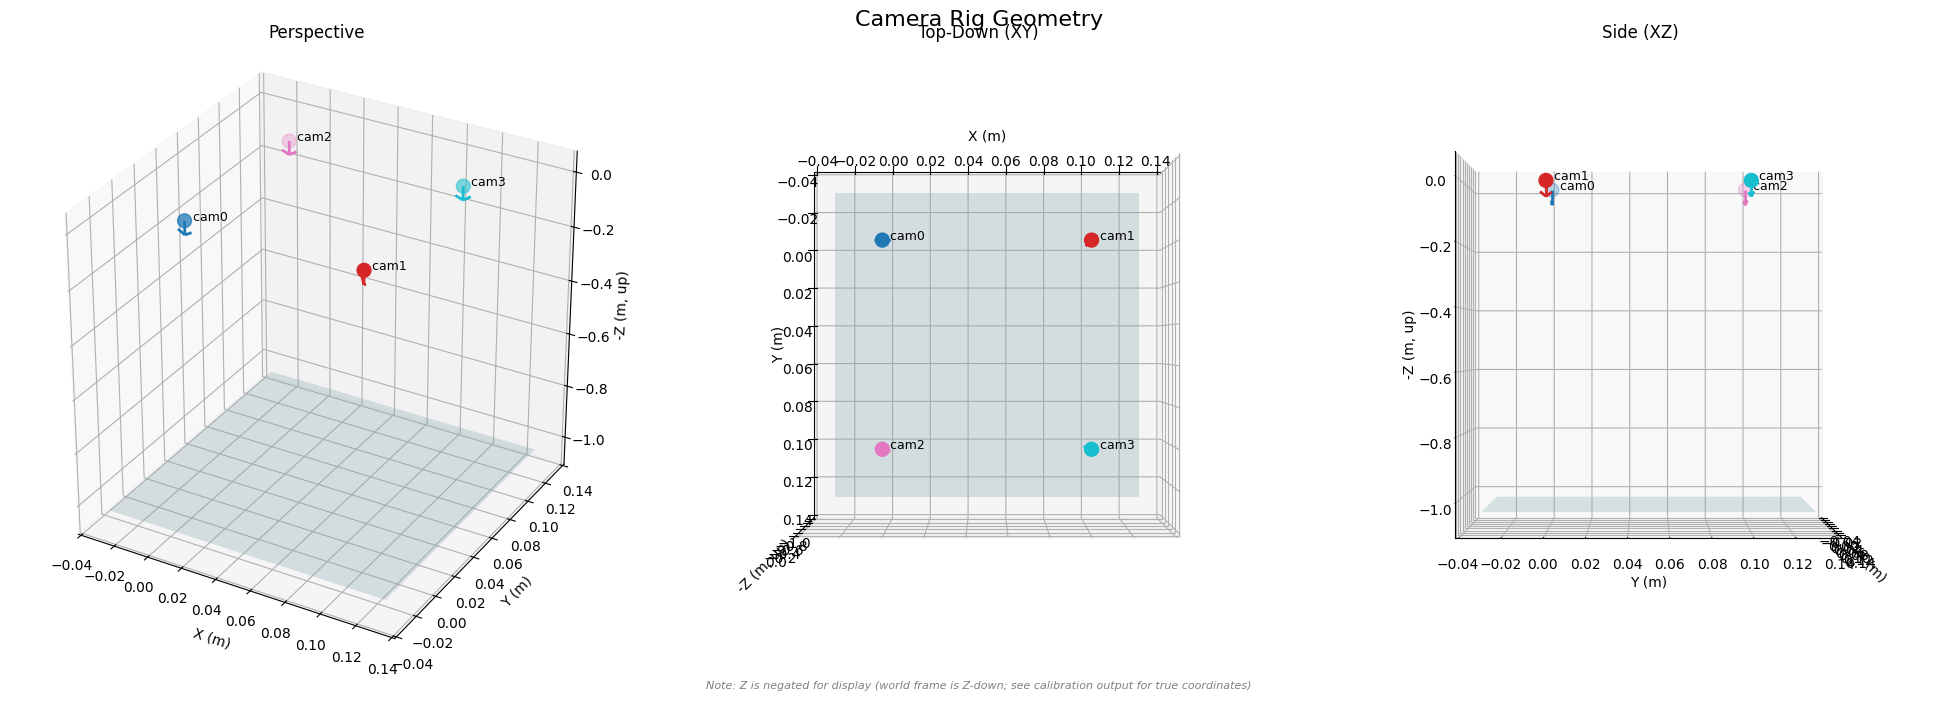

In [6]:
%matplotlib inline
fig = plot_camera_rig(result, title="Camera Rig Geometry")
plt.show()
plt.close()

## Intrinsic Parameters

Focal lengths and principal points for each camera. For synthetic data these are
ground truth values passed through to calibration; for real data they come from
Stage 1 (in-air) calibration.

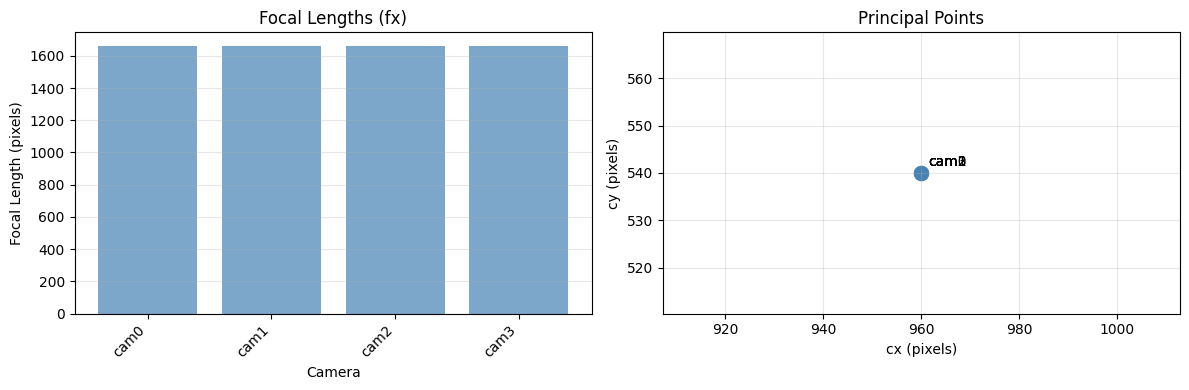

In [7]:
def plot_intrinsics_summary(result):
    """Side-by-side focal length bar chart and principal point scatter."""
    cam_names = sorted(result.cameras.keys())
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    fx_vals = [result.cameras[c].intrinsics.K[0, 0] for c in cam_names]
    cx_vals = [result.cameras[c].intrinsics.K[0, 2] for c in cam_names]
    cy_vals = [result.cameras[c].intrinsics.K[1, 2] for c in cam_names]

    x = np.arange(len(cam_names))
    ax1.bar(x, fx_vals, color='steelblue', alpha=0.7)
    ax1.set_xlabel('Camera')
    ax1.set_ylabel('Focal Length (pixels)')
    ax1.set_title('Focal Lengths (fx)')
    ax1.set_xticks(x)
    ax1.set_xticklabels(cam_names, rotation=45, ha='right')
    ax1.grid(axis='y', alpha=0.3)

    ax2.scatter(cx_vals, cy_vals, s=100, color='steelblue', alpha=0.7)
    for i, cam in enumerate(cam_names):
        ax2.annotate(cam, (cx_vals[i], cy_vals[i]), xytext=(5, 5), textcoords='offset points')
    ax2.set_xlabel('cx (pixels)')
    ax2.set_ylabel('cy (pixels)')
    ax2.set_title('Principal Points')
    ax2.grid(alpha=0.3)

    fig.tight_layout()
    return fig

fig = plot_intrinsics_summary(result)
plt.show()
plt.close()

## Diagnostics

### Per-Camera Reprojection Error

A bar chart of per-camera RMS errors quickly reveals whether any camera is performing
worse than the others. Cameras with high error often have poor intrinsic calibration
or insufficient board observations.

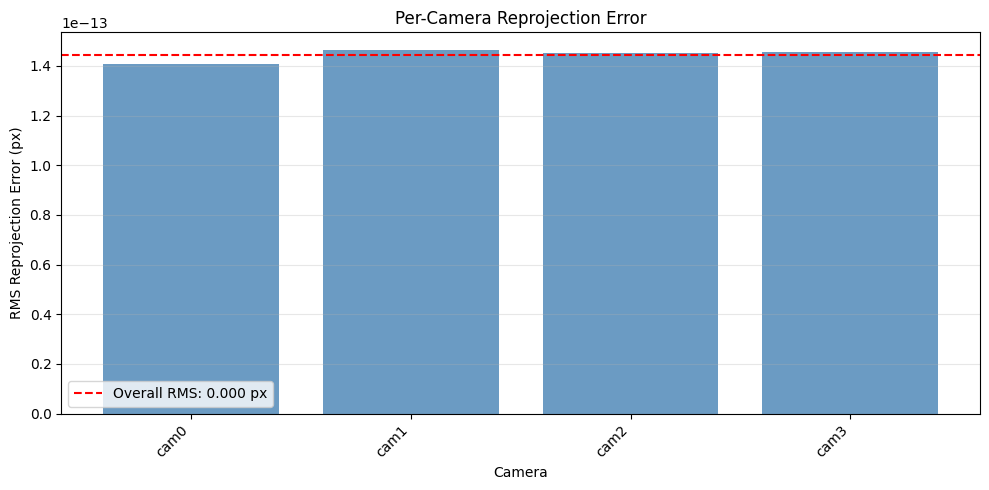

Cameras with error > 2x the average may need re-calibration.


In [8]:
fig = plot_per_camera_error(result)
plt.show()
plt.close()

print("Cameras with error > 2x the average may need re-calibration.")

### Reprojection Error Distribution

The histogram shows the overall distribution of per-corner errors across all cameras
and frames. A well-calibrated rig produces a tight distribution centered near zero.

Residuals come from recomputing projections against detections.

Error statistics:
  Mean:            0.000 px
  Median:          0.000 px
  95th percentile: 0.000 px
  Max:             0.000 px


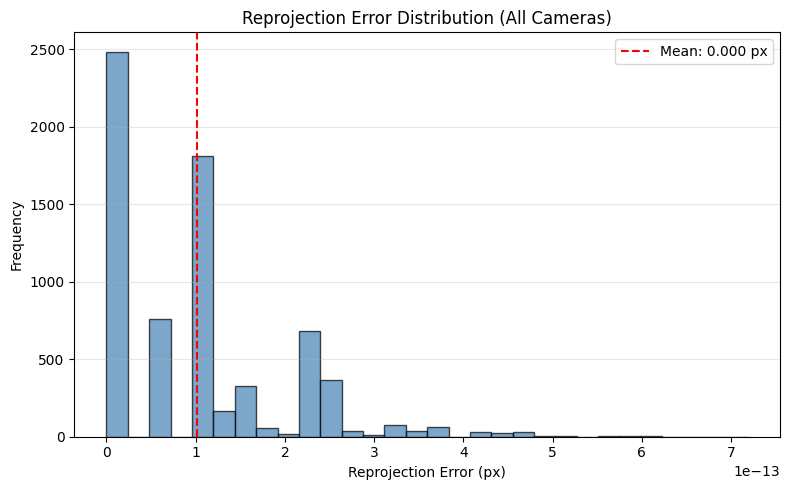

In [9]:
# Identify auxiliary cameras (if any) for split display
aux_cameras = {name for name, cc in result.cameras.items() if cc.is_auxiliary}

if reprojection_result is not None:
    fig = plot_error_distribution(reprojection_result, auxiliary_cameras=aux_cameras or None)
    plt.show()
    plt.close()
elif result.diagnostics.per_corner_residuals is not None:
    # Build a ReprojectionErrors from saved residuals (e.g. a saved calibration.json --
    # see the CLI tutorial's save_detailed_residuals option)
    from aquacal.validation.reprojection import ReprojectionErrors

    camera_labels = (
        np.array(result.diagnostics.per_corner_camera_labels, dtype=object)
        if result.diagnostics.per_corner_camera_labels is not None
        else None
    )
    stored = ReprojectionErrors(
        rms=result.diagnostics.reprojection_error_rms,
        per_camera=result.diagnostics.reprojection_error_per_camera,
        per_frame=result.diagnostics.per_frame_errors or {},
        residuals=result.diagnostics.per_corner_residuals,
        num_observations=len(result.diagnostics.per_corner_residuals),
        camera_labels=camera_labels,
    )
    fig = plot_error_distribution(stored, auxiliary_cameras=aux_cameras or None)
    plt.show()
    plt.close()
else:
    print("Skipped — per-corner residuals not available for this data source.")
    print(f"Overall RMS from calibration: {result.diagnostics.reprojection_error_rms:.3f} px")

### Interface Distance Recovery (Synthetic Only)

The water surface Z-coordinate (`water_z`) is the key refractive parameter.
Comparing estimated values to ground truth tells you how well Stage 3 converged.

Mean absolute interface distance error: 0.00 mm


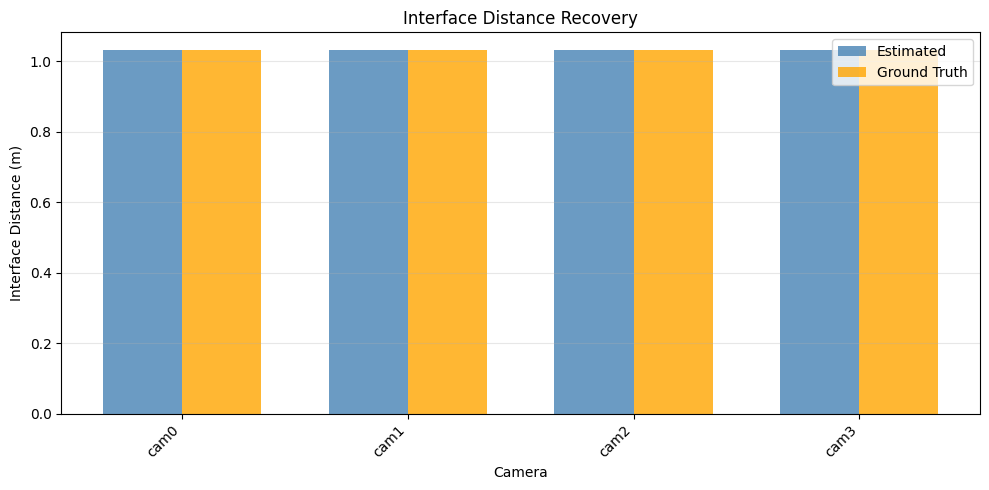

In [10]:
def plot_interface_recovery(result, scenario):
    """Grouped bar chart comparing estimated vs ground-truth water_z."""
    cam_names = sorted(result.cameras.keys())
    estimated = [result.cameras[c].water_z for c in cam_names]
    ground_truth = [scenario.water_zs[c] for c in cam_names]

    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(cam_names))
    width = 0.35

    ax.bar(x - width / 2, estimated, width, label='Estimated', color='steelblue', alpha=0.8)
    ax.bar(x + width / 2, ground_truth, width, label='Ground Truth', color='orange', alpha=0.8)

    ax.set_xlabel('Camera')
    ax.set_ylabel('Interface Distance (m)')
    ax.set_title('Interface Distance Recovery')
    ax.set_xticks(x)
    ax.set_xticklabels(cam_names, rotation=45, ha='right')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    fig.tight_layout()

    mean_err = np.mean([abs(e - g) for e, g in zip(estimated, ground_truth)])
    print(f"Mean absolute interface distance error: {mean_err * 1000:.2f} mm")
    return fig

if scenario is not None:
    fig = plot_interface_recovery(result, scenario)
    plt.show()
    plt.close()
else:
    print("Skipped — ground truth not available for real data.")
    print("Estimated water_z values are shown in the result summary above.")

### 3D Reconstruction Error

Reprojection error measures 2D fit quality, but 3D reconstruction error is the ultimate
accuracy metric. We triangulate board corners from multiple cameras and compare the
recovered inter-corner distances to the known board geometry.

3D Reconstruction Quality:
  Signed mean error: 0.000 mm
  RMSE:              0.000 mm
  Comparisons:       3140


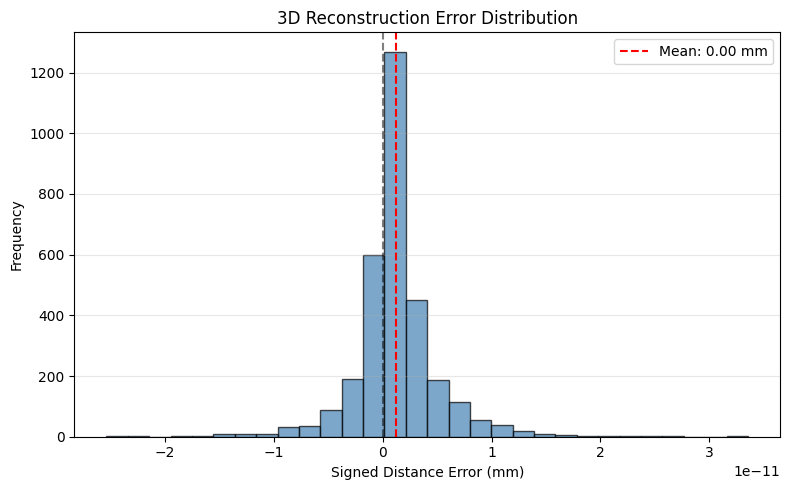

In [11]:
from aquacal.validation.reconstruction import compute_3d_distance_errors

dist_errors = compute_3d_distance_errors(
    calibration=result,
    detections=detections,
    board=board,
    include_per_pair=False,
    include_spatial=True,
)

print("3D Reconstruction Quality:")
print(f"  Signed mean error: {dist_errors.signed_mean * 1000:.3f} mm")
print(f"  RMSE:              {dist_errors.rmse * 1000:.3f} mm")
print(f"  Comparisons:       {dist_errors.num_comparisons}")

spatial_measurements = dist_errors.spatial
if spatial_measurements is not None:
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(
        spatial_measurements.signed_errors * 1000,
        bins=30, color='steelblue', alpha=0.7, edgecolor='black',
    )
    ax.axvline(0, color='black', linestyle='--', alpha=0.5)
    ax.axvline(
        dist_errors.signed_mean * 1000, color='red', linestyle='--',
        label=f'Mean: {dist_errors.signed_mean * 1000:.2f} mm',
    )
    ax.set_xlabel('Signed Distance Error (mm)')
    ax.set_ylabel('Frequency')
    ax.set_title('3D Reconstruction Error Distribution')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
    plt.close()

### Common Issues Checklist

| Symptom | Likely Cause | Fix |
|---------|-------------|-----|
| High error for one camera | Poor intrinsic calibration | Re-calibrate intrinsics with more frames, check for motion blur |
| High error in image corners | Distortion model insufficient | Try rational model (8 coefficients) |
| Interface distance not converging | Initial estimate too far from truth | Provide better `initial_water_z` in config |
| Interface distances differ between cameras | Degenerate board poses | Ensure board is visible at varied angles and depths |
| High 3D reconstruction error | Systematic bias | Check that `n_water` is correct for your water type |
| Reprojection < 1px but 3D error high | Overfitting to 2D | Verify interface distance initialization, add validation frames |

## Saving and Loading Results

AquaCal provides utilities to save and load calibration results in JSON format.

In [12]:
# Save calibration result
# save_calibration(result, "output/calibration.json")

# Load it back later
# loaded = load_calibration("output/calibration.json")

print("Calibration results can be saved to JSON for later use.")
print("See aquacal.io.serialization.save_calibration() and load_calibration().")

Calibration results can be saved to JSON for later use.
See aquacal.io.serialization.save_calibration() and load_calibration().


## Summary

In this tutorial you learned how to:

1. Load synthetic calibration data
2. Run the calibration pipeline (extrinsic initialization and joint refractive bundle adjustment)
3. Inspect camera rig geometry, intrinsic parameters, and interface distances
4. Diagnose calibration quality with per-camera, distribution, and 3D error analysis
5. Save and load calibration results

**Next:** Explore [why refractive calibration matters](02_synthetic_validation.ipynb) with
controlled experiments comparing refractive vs non-refractive models, or work through the
[CLI tutorial](03_cli_walkthrough.md) to calibrate a real hardware rig with the full example
dataset.

- [User Guide](../guide/index.md): Comprehensive documentation on calibration theory and best practices